## Cargando librerias

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Cargando Tabla limpia

In [4]:
df = pd.read_csv("../processed/df_total_clean_CA1.csv")

/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_22627/3820689758.py:1: DtypeWarning: Columns (14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../processed/df_total_clean_CA1.csv")


In [5]:
df["date"] = pd.to_datetime(df["date"])

### Creación features temporales 

In [7]:
df = df.sort_values(["item_id", "date"])

#### Lags 
El valor pasado de una variables.\
Usa el pasado para predecir el futuro.

In [8]:
df["lag_7"] = df.groupby("item_id")["sales"].shift(7)
df["lag_28"] = df.groupby("item_id")["sales"].shift(28)

#### Rolling Mean 

Es un promedio móvil. Es el promedio de los últimos N días 

In [10]:
# usamos .shift(1) para evitar leakage.
df["rolling_mean_7"] = (df.groupby("item_id")["sales"].shift(1).rolling(7).mean())

In [15]:
df["rolling_mean_28"] = (df.groupby("item_id")["sales"].shift(1).rolling(28).mean())

In [16]:
# variables temporales útiles
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["dayofweek"] = df["date"].dt.dayofweek

In [17]:
df.isnull().sum()

id                     0
item_id                0
dept_id                0
cat_id                 0
store_id               0
state_id               0
d                      0
sales                  0
date                   0
wm_yr_wk               0
weekday                0
wday                   0
month                  0
year                   0
snap_CA                0
snap_TX                0
snap_WI                0
has_event              0
sell_price             0
is_weekend             0
lag_7              21343
lag_28             85372
rolling_mean_7     21343
dayofweek              0
rolling_mean_28    85372
dtype: int64

In [13]:
# Como tengo has_event elimino las columnas de eventos que no la usare 
df = df.drop(columns=["event_name_1", "event_type_1", "event_name_2", "event_type_2"])

In [19]:
# Eliminamos los NaN que se crearon por el rolling 7, 28 y los lag 7, 28
df = df.dropna(subset=["lag_7", "lag_28", "rolling_mean_7", "rolling_mean_28"])

In [21]:
df.shape

(4617523, 25)

### Definiendo features Baseline

In [22]:
features = ["sell_price",
            "is_weekend",
            "has_event",
            "dayofweek",
            "month",
            "lag_7",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_28"]

In [23]:
target = "sales"

### Split Temporal 

In [24]:
train = df[df["date"] < "2015-01-01"]
test  = df[df["date"] >= "2015-01-01"]

In [25]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

### Modelo baseline

In [27]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
preds = model.predict(X_test)


In [30]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.1895462890620543
MAE: 1.0992836473952257


Modelo Random Forest:\
Mi media de ventas estaba alrededor de ~ 1.3 unidades por día.

* MAE ~ 1.10 -> el error promedio es casi del tamaño de la venta media
* RMSE ~ 2.19 -> hay errores grandes (penaliza más outliers)

In [32]:
#la predicción para hoy será igual a lo que vendí hace días - > modelo naive semanal
baseline_preds = X_test["lag_7"]
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))
mae_baseline = mean_absolute_error(y_test, baseline_preds)

print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mae_baseline)

Baseline RMSE: 2.8588989513488112
Baseline MAE: 1.277839649004758


Tu modelo mejora respecto al baseline:

RMSE mejora ≈
(2.86 - 2.19) / 2.86 ≈ 23% de mejora

MAE mejora ≈
(1.28 - 1.10) / 1.28 ≈ 14% de mejora

Eso es una mejora clara y significativa.

In [33]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

importance

rolling_mean_7     0.652571
rolling_mean_28    0.112944
sell_price         0.054029
lag_7              0.049524
lag_28             0.045822
month              0.038644
dayofweek          0.031319
is_weekend         0.010807
has_event          0.004340
dtype: float64

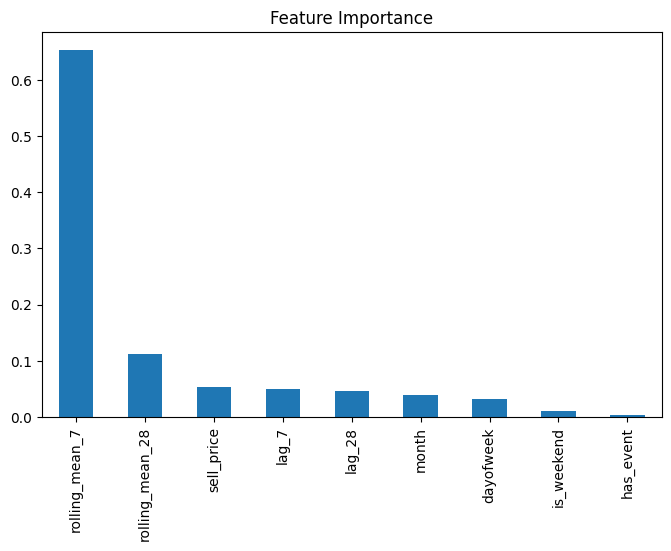

In [35]:
importance.plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance")
plt.show()